# Frobenius Group of Order 21: Scale Growth Comparison

Focused on Stage 1 + Stage 2 training. Stage 1 trains directions on the sphere with frozen scales.
Stage 2 unfreezes scales only, comparing two regimes:

1. **Tied scales**: one shared `scale_in` and `scale_out` scalar for all neurons
2. **Per-neuron scales**: independent `scale_in_m` and `scale_out_m` per neuron

**Group**: G = C_7 ⋊ C_3 (Frobenius group, order 21)

In [1]:
import sys
sys.path.insert(0, '..')

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

from src.tasks import Frobenius21Multiplication
from src.basis import Frobenius21Basis
from src.model import WideNetworkScaleSphere
from src.utils import cross_entropy_high_precision, accuracy, project_gradient_to_tangent_space
from src.plotting import setup_plot_style

setup_plot_style()

## 1. Configuration

In [2]:
# Model
WIDTH = 512
ACT_TYPE = 'Quad'
INIT_SCALE = 0.5
SHARE_EMBED = False

# Stage 1: Projected GD on sphere (directions only, scales frozen)
S1_LR = 1e-1
S1_EPOCHS = 65000
S1_PRINT_EVERY = 1000

# Stage 2: Scale optimization (directions frozen)
S2_LR = 1e-1
S2_EPOCHS = 40000
S2_PRINT_EVERY = 1000

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
device = torch.device('cpu')
vocab_size = 21

print(f'Group: G = C_7 ⋊ C_3, |G| = {vocab_size}')
print(f'Model: width={WIDTH}, act={ACT_TYPE}, share_embed={SHARE_EMBED}')
print(f'Stage 1: SGD lr={S1_LR}, {S1_EPOCHS} epochs')
print(f'Stage 2: SGD lr={S2_LR}, {S2_EPOCHS} epochs')

Group: G = C_7 ⋊ C_3, |G| = 21
Model: width=512, act=Quad, share_embed=False
Stage 1: SGD lr=0.1, 65000 epochs
Stage 2: SGD lr=0.1, 40000 epochs


## 2. Initialize Task, Basis, and Model

In [3]:
task = Frobenius21Multiplication()
basis = Frobenius21Basis()
data, labels = task.generate_all_data(device)

model = WideNetworkScaleSphere(
    d_vocab=vocab_size,
    width=WIDTH,
    act_type=ACT_TYPE,
    init_scale=INIT_SCALE,
    share_embed=SHARE_EMBED,
).to(device)

print(f'Task: {task}')
print(f'Dataset: {len(data)} samples')
print(f'W_in: {model.W_in.shape}, W_out: {model.W_out.shape}')
print(f'scale_in={model.scale_in.item():.4f}, scale_out={model.scale_out.item():.4f}')

Task: Frobenius21Multiplication(vocab_size=21)
Dataset: 441 samples
W_in: torch.Size([512, 42]), W_out: torch.Size([21, 512])
scale_in=0.5000, scale_out=0.5000


## 3. Stage 1: Projected GD on Sphere

Train directions $\theta_m, \xi_m$ on the unit sphere with scales frozen at `INIT_SCALE`.

In [4]:
# Freeze scales
model.scale_in.requires_grad = False
model.scale_out.requires_grad = False

optimizer_s1 = optim.SGD([model.W_in, model.W_out], lr=S1_LR)

s1_losses = []
s1_accs = []

print('=' * 60)
print('Stage 1: Projected GD (Directions only, Scales frozen)')
print('=' * 60)
print(f'Fixed scale_in={model.scale_in.item():.4f}, scale_out={model.scale_out.item():.4f}')

for epoch in range(S1_EPOCHS):
    optimizer_s1.zero_grad()
    logits = model(data)
    loss = cross_entropy_high_precision(logits, labels)
    acc = accuracy(logits, labels)
    loss.backward()
    with torch.no_grad():
        model.W_in.grad = project_gradient_to_tangent_space(
            model.W_in.data, model.W_in.grad, dim=1
        )
        model.W_out.grad = project_gradient_to_tangent_space(
            model.W_out.data, model.W_out.grad, dim=0
        )
    optimizer_s1.step()
    model.normalize_directions()
    s1_losses.append(loss.item())
    s1_accs.append(acc)
    if epoch % S1_PRINT_EVERY == 0:
        print(f'Epoch {epoch:6d} | Loss: {loss.item():.4f} | Acc: {acc:.4f}')

print(f'\nStage 1 Final | Loss: {s1_losses[-1]:.4f} | Acc: {s1_accs[-1]:.4f}')

# Save frozen directions for Stage 2
W_in_frozen = model.W_in.detach().clone()
W_out_frozen = model.W_out.detach().clone()
W_in_frozen.requires_grad = False
W_out_frozen.requires_grad = False

Stage 1: Projected GD (Directions only, Scales frozen)
Fixed scale_in=0.5000, scale_out=0.5000
Epoch      0 | Loss: 1342.6349 | Acc: 0.0340


Epoch   1000 | Loss: 1342.6211 | Acc: 0.0748


Epoch   2000 | Loss: 1342.6077 | Acc: 0.1224


Epoch   3000 | Loss: 1342.5945 | Acc: 0.1905


Epoch   4000 | Loss: 1342.5817 | Acc: 0.2358


...

Epoch  61000 | Loss: 1342.3853 | Acc: 0.9977


Epoch  62000 | Loss: 1342.3848 | Acc: 0.9977


Epoch  63000 | Loss: 1342.3843 | Acc: 0.9977


Epoch  64000 | Loss: 1342.3838 | Acc: 0.9977



Stage 1 Final | Loss: 1342.3834 | Acc: 1.0000


## 4. Stage 2: Scale Optimization

Directions are frozen from Stage 1. We add a single scale $a_m$ multiplied directly onto the logits:

$$\text{logits} = a \cdot \frac{1}{M} \sum_m \sigma(\text{embed} \cdot \theta_m) \, \xi_m$$

Two cases:

- **Tied**: $a_m = a$ for all $m$ — one shared scalar multiplying the full logit vector
- **Per-neuron**: independent $a_m$ for each neuron, scaling its contribution before summing

In [5]:
# Embed data once (directions are frozen)
one_hot = F.one_hot(data, num_classes=vocab_size).float()
embed = one_hot.view(data.shape[0], -1)  # (N, 2*vocab_size) for unshared

# Pre-compute neuron activations (fixed throughout Stage 2)
with torch.no_grad():
    post_act = (embed @ W_in_frozen.T) ** 2   # (N, M): sigma(embed · theta_m)

# Both cases use: logits = (post_act * a) @ W_out.T / M
# Tied:       a is a scalar  -> post_act * a broadcasts to (N, M)
# Per-neuron: a is (M,)     -> post_act * a scales each neuron independently

# ================================================================
# Case 1: Tied scale  a_m = a  (scalar)
# ================================================================
a_tied = nn.Parameter(torch.tensor([float(INIT_SCALE)]))
opt_tied = optim.SGD([a_tied], lr=S2_LR)

s2_tied_losses = []
s2_tied_a_hist = []

print('Stage 2 - Tied scale (a_m = a):')
for epoch in range(S2_EPOCHS):
    opt_tied.zero_grad()
    logits = (post_act * a_tied) @ W_out_frozen.T / WIDTH
    loss = cross_entropy_high_precision(logits, labels)
    loss.backward()
    opt_tied.step()
    s2_tied_losses.append(loss.item())
    s2_tied_a_hist.append(a_tied.item())
    if epoch % S2_PRINT_EVERY == 0:
        print(f'  Epoch {epoch:5d} | Loss: {loss.item():.4f} | a={a_tied.item():.4f}')
print(f'  Final | Loss: {s2_tied_losses[-1]:.4f} | a={s2_tied_a_hist[-1]:.4f}')

# ================================================================
# Case 2: Per-neuron scale  a_m  (vector of shape (M,))
# ================================================================
a_pn = nn.Parameter(torch.full((WIDTH,), float(INIT_SCALE)))
opt_pn = optim.SGD([a_pn], lr=S2_LR * WIDTH)  # *WIDTH to match grad scale with tied

s2_pn_losses = []
s2_pn_traj = []   # (S2_EPOCHS, M)

print(f'\nStage 2 - Per-neuron scale (a_m):')
for epoch in range(S2_EPOCHS):
    opt_pn.zero_grad()
    logits = (post_act * a_pn) @ W_out_frozen.T / WIDTH
    loss = cross_entropy_high_precision(logits, labels)
    loss.backward()
    opt_pn.step()
    s2_pn_losses.append(loss.item())
    s2_pn_traj.append(a_pn.detach().clone().numpy())
    if epoch % S2_PRINT_EVERY == 0:
        print(f'  Epoch {epoch:5d} | Loss: {loss.item():.4f} | '
              f'a_mean={a_pn.mean().item():.4f}±{a_pn.std().item():.4f}')
s2_pn_traj = np.stack(s2_pn_traj)  # (S2_EPOCHS, M)
print(f'  Final | Loss: {s2_pn_losses[-1]:.4f}')

Stage 2 - Tied scale (a_m = a):
  Epoch     0 | Loss: 1341.6301 | a=0.7008


  Epoch  1000 | Loss: 975.6702 | a=191.8938


  Epoch  2000 | Loss: 696.7914 | a=358.6755


  Epoch  3000 | Loss: 506.4216 | a=496.3701


  Epoch  4000 | Loss: 383.4988 | a=606.9976


...

  Epoch 36000 | Loss: 26.7535 | a_mean=1371.2009±321.3525


  Epoch 37000 | Loss: 25.9915 | a_mean=1379.3829±324.0428


  Epoch 38000 | Loss: 25.2725 | a_mean=1387.3279±326.6620


  Epoch 39000 | Loss: 24.5929 | a_mean=1395.0497±329.2144


  Final | Loss: 23.9503


## 5. Plots

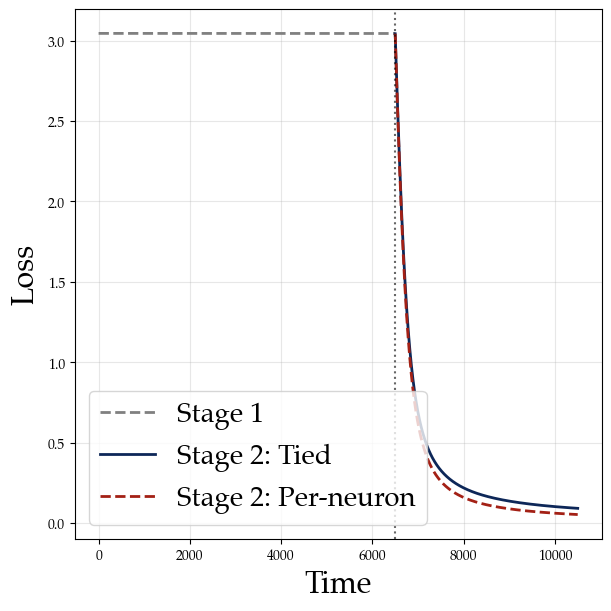

In [6]:
# Loss curve across Stage 1 + Stage 2 (x-axis = time t = lr * epoch)
s1_times = np.arange(len(s1_losses)) * S1_LR
s2_offset = s1_times[-1] + S2_LR  # stage 2 starts after stage 1 ends
s2_times  = s2_offset + np.arange(len(s2_tied_losses)) * S2_LR  # unadjusted lr for both

fig, ax = plt.subplots(figsize=(6, 6), constrained_layout=True)
ax.plot(s1_times, np.array(s1_losses)/21**2, color='gray', linewidth=2, linestyle='--', label='Stage 1')
ax.plot(s2_times, np.array(s2_tied_losses)/21**2, color='#0D2758', linewidth=2, label='Stage 2: Tied')
ax.plot(s2_times, np.array(s2_pn_losses)/21**2, color='#A32015', linewidth=2, linestyle='--', label='Stage 2: Per-neuron')
ax.axvline(x=s2_offset, color='black', linestyle=':', linewidth=1.5, alpha=0.6)
ax.set_xlabel('Time', fontsize=22)
ax.set_ylabel('Loss', fontsize=22)
ax.legend(fontsize=20, loc='lower left')
ax.grid(True, alpha=0.3)
plt.savefig('../figures/frobenius21_scale_comparison_loss.jpg', format='jpg', dpi=300, bbox_inches='tight')
plt.show()

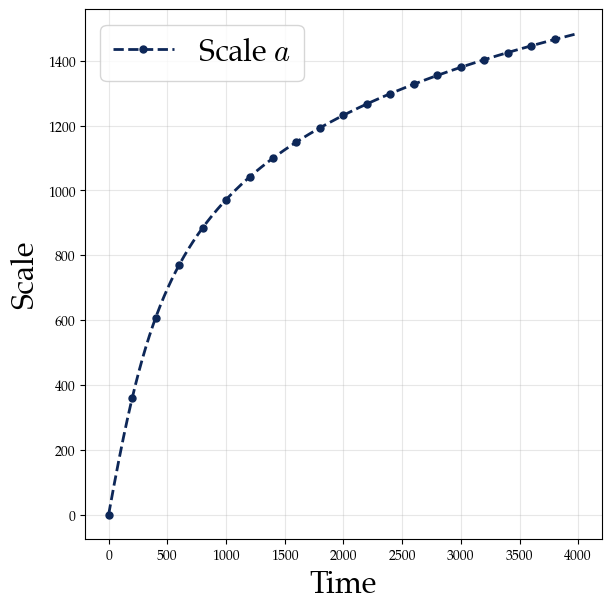

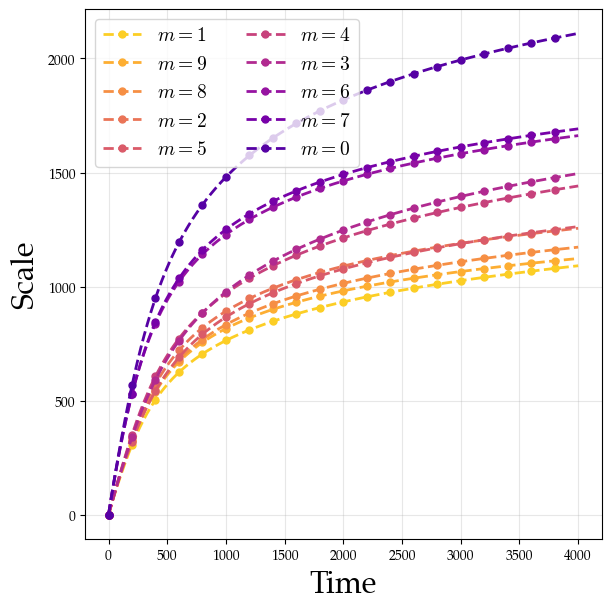

In [7]:
s2_ep_only = np.arange(S2_EPOCHS)
times_tied = s2_ep_only * S2_LR
times_pn   = s2_ep_only * S2_LR * WIDTH  # effective lr for per-neuron
markevery  = max(1, S2_EPOCHS // 20)

# ── Plot 1: Tied scale ────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 6), constrained_layout=True)
ax.plot(times_tied, s2_tied_a_hist, color='#0D2758', linewidth=2,
        linestyle='--', marker='o', markersize=5, markevery=markevery, label='Scale $a$')
ax.set_xlabel('Time', fontsize=22)
ax.set_ylabel('Scale', fontsize=22)
ax.legend(fontsize=22)
ax.grid(True, alpha=0.3)
plt.savefig('../figures/frobenius21_scale_tied.jpg', format='jpg', dpi=300, bbox_inches='tight')
plt.show()

# ── Plot 2: First 20 neurons, ranked by final scale ───────────────────────
first20_idx  = np.arange(10)
final_scales = s2_pn_traj[-1]
top20_sorted = first20_idx[np.argsort(final_scales[first20_idx])]

cmap_pn = plt.cm.plasma
n_top   = len(top20_sorted)

fig, ax = plt.subplots(figsize=(6, 6), constrained_layout=True)
for rank, m in enumerate(top20_sorted):
    color = cmap_pn(0.90 - 0.75 * rank / max(n_top - 1, 1))
    ax.plot(times_tied, s2_pn_traj[:, m],
            color=color, linewidth=2,
            linestyle='--', marker='o', markersize=5, markevery=markevery,
            label=f'$m={m}$')

ax.set_xlabel('Time', fontsize=22)
ax.set_ylabel('Scale', fontsize=22)
ax.legend(fontsize=14, ncol=2, loc='upper left')
ax.grid(True, alpha=0.3)
plt.savefig('../figures/frobenius21_scale_perneuron.jpg', format='jpg', dpi=300, bbox_inches='tight')
plt.show()